# AI-Generated vs Human-Generated Text Classification System 

Build an end-to-end Machine Learning/NLP project that detects whether a given text sample is 
authored by a human or generated by an AI model.
This is a highly relevant real-world problem for:
• Media companies (fake news detection)
• Education (AI-written assignments)
• Finance & Banking (AI-written fraud/scam emails)
• Healthcare (AI-written clinical notes detection)
• Marketing (AI vs human generated ads)

1. Problem Understanding & Business Use Cases
Define at least 3 real applications

2. Data Ingestion & Preprocessing
Dataset contains:
• text
• label (Human / AI model e.g., GPT, Bard, Claude)

About Dataset:
Around 500K essays are available in this dataset, both created by AI and written by Human.

link: https://www.kaggle.com/datasets/shanegerami/ai-vs-human-text?utm_source=chatgpt.com

 To check how model works with other texts, I check its Metrics with the other ine

 link: https://www.kaggle.com/datasets/shamimhasan8/ai-vs-human-text-dataset?utm_source=chatgpt.com&select=ai_vs_human_text.csv

In [1]:
#! pip install spacy
#! pip install seaborn

In [9]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

import spacy
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

import warnings
warnings.filterwarnings('ignore')

In [12]:
#Load Dataset
df = pd.read_csv("AI_Human.csv")
print(df.head(5))

                                                text  generated
0  Cars. Cars have been around since they became ...        0.0
1  Transportation is a large necessity in most co...        0.0
2  "America's love affair with it's vehicles seem...        0.0
3  How often do you ride in a car? Do you drive a...        0.0
4  Cars are a wonderful thing. They are perhaps o...        0.0


Generated by AI (1) and Human (0)

In [13]:
# Basic information

print('The Shape of the Data: ', df.shape)
print('\nThe coloumns of the data:\n ', df.columns.to_list())
print('\nThe Data Type:\n ', df.dtypes.value_counts())

The Shape of the Data:  (487235, 2)

The coloumns of the data:
  ['text', 'generated']

The Data Type:
  object     1
float64    1
Name: count, dtype: int64


Dataset contains 2 columns(numeric amd categorical) and has 487235 rows. 

In [14]:
# Statistical summury
print('The Statistical Summary: \n')
df.describe()

The Statistical Summary: 



,generated
count,487235.000000
mean,0.372383
std,0.483440
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [15]:
# Missing values
print('The DataTypes with Non-Null Values: ', df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487235 entries, 0 to 487234
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   text       487235 non-null  object 
 1   generated  487235 non-null  float64
dtypes: float64(1), object(1)
memory usage: 7.4+ MB
The DataTypes with Non-Null Values:  None


In [16]:
print('Missing Values: \n')
df.isnull().sum()

Missing Values: 



text         0
generated    0
dtype: int64

Dataset contains null missing values

In [17]:
# Check duplicates

print(df['text'].duplicated().sum())

0


 DateSet contains 0 identical texts. 

In [18]:
# Target value distibution
df['generated'].value_counts()

generated
0.0    305797
1.0    181438
Name: count, dtype: int64

The dataset is almost evenly split between AI and human-generated text

In [19]:
# Converting generated column to int
df['generated']=df['generated'].astype(int)
print(df.head())

                                                text  generated
0  Cars. Cars have been around since they became ...          0
1  Transportation is a large necessity in most co...          0
2  "America's love affair with it's vehicles seem...          0
3  How often do you ride in a car? Do you drive a...          0
4  Cars are a wonderful thing. They are perhaps o...          0


In [20]:
df['generated'].value_counts()

generated
0    305797
1    181438
Name: count, dtype: int64

 0 for Human, 1 for AI. Dateset is moderately imbalanced. For further comparison i will use not only Accyracy, but alse F1-score and precissiom and recall.

## Text cleaning

To campare metrics I will make a copy of this daset, to compare the effisient of ML-Model for texts with and without punctuation

In [21]:
df_p = df.copy()

In [22]:
# putting all leters in lowercase

df['text'] = df['text'].str.lower()
print(df['text'].head(2))

0    cars. cars have been around since they became ...
1    transportation is a large necessity in most co...
Name: text, dtype: object


In [23]:
df_p['text'] = df_p['text'].str.lower()
print(df_p['text'].head(2))

0    cars. cars have been around since they became ...
1    transportation is a large necessity in most co...
Name: text, dtype: object


In [24]:
# Rempoving all punctuation

df['text']=df['text'].str.replace(r'[^\w\s]', '', regex=True)
print(df['text'].head(2))

# check if any punctuation is still in text
print(df['text'].str.contains(r'[^\w\s]', regex=True, na=False).any())

0    cars cars have been around since they became f...
1    transportation is a large necessity in most co...
Name: text, dtype: object
False


 All texts are without punctuation and all letters are in lowercase

In [25]:
# Calculating text legth

df['length']=df['text'].apply(lambda x: len(str(x).split()))
print(df.head())

                                                text  generated  length
0  cars cars have been around since they became f...          0     584
1  transportation is a large necessity in most co...          0     462
2  americas love affair with its vehicles seems t...          0     742
3  how often do you ride in a car do you drive a ...          0     686
4  cars are a wonderful thing they are perhaps on...          0     863


In [26]:
# Calculating text legth for the second dataset

df_p['length']=df_p['text'].apply(lambda x: len(str(x).split()))
print(df_p.head())

                                                text  generated  length
0  cars. cars have been around since they became ...          0     584
1  transportation is a large necessity in most co...          0     462
2  "america's love affair with it's vehicles seem...          0     744
3  how often do you ride in a car? do you drive a...          0     686
4  cars are a wonderful thing. they are perhaps o...          0     871


In [27]:
# Checking the diffrerence in legth between both texts
print("Mean of text length with punktaution: \n", df.groupby('generated')['length'].mean())
print("Mean of text length without punktaution: \n", df_p.groupby('generated')['length'].mean())
print("Summary statistic of text length without punktaution: \n", df_p.groupby('generated')['length'].describe())
print("Summary statistic of text length with punktaution: \n", df.groupby('generated')['length'].describe())

Mean of text length with punktaution: 
 generated
0    421.701920
1    344.051384
Name: length, dtype: float64
Mean of text length without punktaution: 
 generated
0    421.98518
1    344.40653
Name: length, dtype: float64
Summary statistic of text length without punktaution: 
               count       mean         std   min    25%    50%    75%     max
generated                                                                    
0          305797.0  421.98518  186.870962  14.0  281.0  389.0  520.0  1668.0
1          181438.0  344.40653  117.031491   0.0  274.0  337.0  403.0  1238.0
Summary statistic of text length with punktaution: 
               count        mean         std   min    25%    50%    75%     max
generated                                                                     
0          305797.0  421.701920  186.808191  14.0  281.0  389.0  520.0  1668.0
1          181438.0  344.051384  116.984152   0.0  273.0  336.0  403.0  1236.0


Model performance may be partially influenced by text length differences between classes.

Minimal preprocessing was applied, as stylistic features 
(e.g., stopwords, word forms) are important for distinguishing 
between human and AI-generated text.

In [28]:
# for one more comparison dataset with truncated text will be created, to see how good Model 
#can decide between classes if texts have no different in length. 

df_t = df.copy()


In [29]:
df_t['text_100']=df_t['text'].apply (lambda x: ' '.join(x.split()[:100]))
df_t['text_300']=df_t['text'].apply (lambda x: ' '.join(x.split()[:300]))
df_t['text_500']=df_t['text'].apply (lambda x: ' '.join(x.split()[:500]))
df_t.head()

,text,generated,length,text_100,text_300,text_500
0,cars cars have been around since they became f...,0,584,cars cars have been around since they became f...,cars cars have been around since they became f...,cars cars have been around since they became f...
1,transportation is a large necessity in most co...,0,462,transportation is a large necessity in most co...,transportation is a large necessity in most co...,transportation is a large necessity in most co...
2,americas love affair with its vehicles seems t...,0,742,americas love affair with its vehicles seems t...,americas love affair with its vehicles seems t...,americas love affair with its vehicles seems t...
3,how often do you ride in a car do you drive a ...,0,686,how often do you ride in a car do you drive a ...,how often do you ride in a car do you drive a ...,how often do you ride in a car do you drive a ...
4,cars are a wonderful thing they are perhaps on...,0,863,cars are a wonderful thing they are perhaps on...,cars are a wonderful thing they are perhaps on...,cars are a wonderful thing they are perhaps on...


after truncation three columns with text length 100,300 and 500 were created. This should helps us to understend hor length impacts on the Model's decision

## EDA

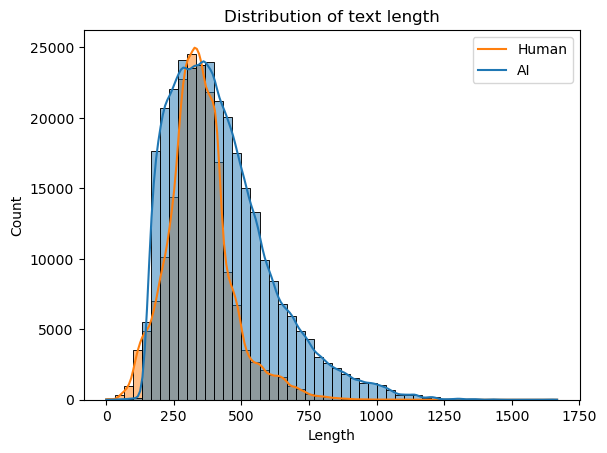

In [30]:
# distribution of length of words
sns.histplot(x='length',hue = "generated", data=df, kde=True, bins=50)
plt.title("Distribution of text length")
plt.legend(["Human", "AI"])
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()
plt.show()

 We see positive skewness. It means that the most texts are short, they contains obout 250-450 words. 
Although there is significant overlap in text length between classes, AI-generated texts tend to have longer tails, which may influence model predictions.

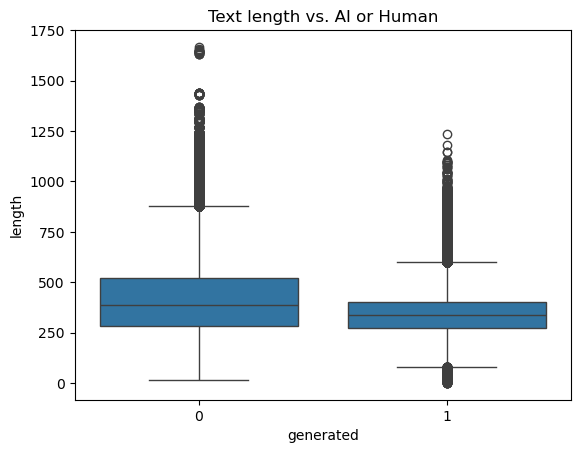

In [31]:
# text length vs label(AI or Human)
sns.boxplot(x='generated', y='length', data=df)
plt.title("Text length vs. AI or Human")
plt.show()

It is common that people mostly write longer texts. AI write shorter texts. 

In [32]:
# Analysing most common words
from collections import Counter
gr = df['generated'].unique()
r =[]
for g in gr:
    text = ' '.join(df[df['generated'] == g]['text'])
    w = text.split()
    counter = Counter(w)
    most_com = counter.most_common(10)
    for w, freq in most_com:
        r.append({
            "label": g,
            "word": w,
            "frequency": freq
        })
df_com = pd.DataFrame(r)
print(df_com)

    label  word  frequency
0       0   the    6168756
1       0    to    4438012
2       0     a    3051226
3       0   and    2918263
4       0    of    2462468
5       0    in    2142239
6       0  that    2104072
7       0    is    1930167
8       0    it    1633479
9       0   you    1551583
10      1   the    2622253
11      1   and    2144141
12      1    to    2133951
13      1     a    1530940
14      1    of    1511436
15      1    in    1164996
16      1  that     863972
17      1    is     803533
18      1   for     724214
19      1   can     722494


We created a dataframe with the most common words for both AI- and human-generated texts. 
However, these words are typical for the English language and do not sufficiently capture 
the differences between AI- and human-written texts.

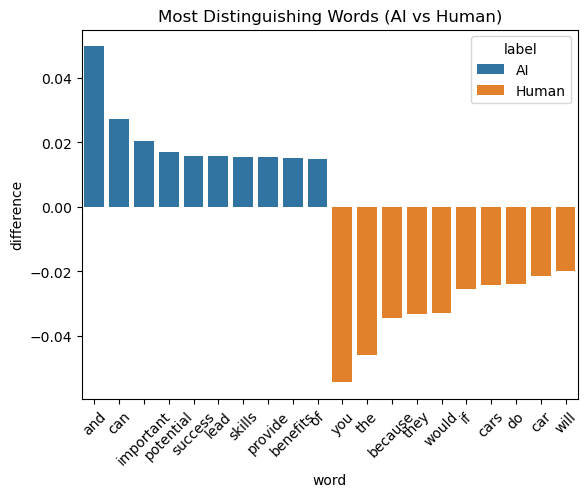

In [33]:
# most common words pre class
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df["text"])

X_human = X[(df["generated"] == 0).values]
X_ai = X[(df["generated"] == 1).values]

human_scores = X_human.mean(axis=0)
ai_scores = X_ai.mean(axis=0)

feature_names = vectorizer.get_feature_names_out()

# difference
diff_df = pd.DataFrame({
    "word": feature_names,
    "difference": (ai_scores - human_scores).A1
})

# top words
top_ai = diff_df.sort_values(by="difference", ascending=False).head(10).copy()
top_human = diff_df.sort_values(by="difference", ascending=True).head(10).copy()

top_ai["label"] = "AI"
top_human["label"] = "Human"

df_plot = pd.concat([top_ai, top_human])

# plot
sns.barplot(x="word", y="difference", hue="label", data=df_plot)
plt.xticks(rotation=45)
plt.title("Most Distinguishing Words (AI vs Human)")
plt.show()

TF-IDF analysis revealed clear differences in word usage patterns between AI-generated and human-written texts.

AI-generated texts tend to use more formal and abstract vocabulary 
(e.g., "important", "potential", "benefits"), reflecting a structured and generalized writing style.

In contrast, human-written texts rely more on common and conversational words 
(e.g., "you", "because", "they"), indicating a more natural and less formal language use.

These findings suggest that the model distinguishes between classes based on subtle stylistic differences 
rather than simple word frequency.

In [34]:
# Building Wordclouds for Human and AI using text after truncation

human = " ".join(df[df['generated']==0]['text'])
ai = " ".join(df[df['generated']==1]['text'])

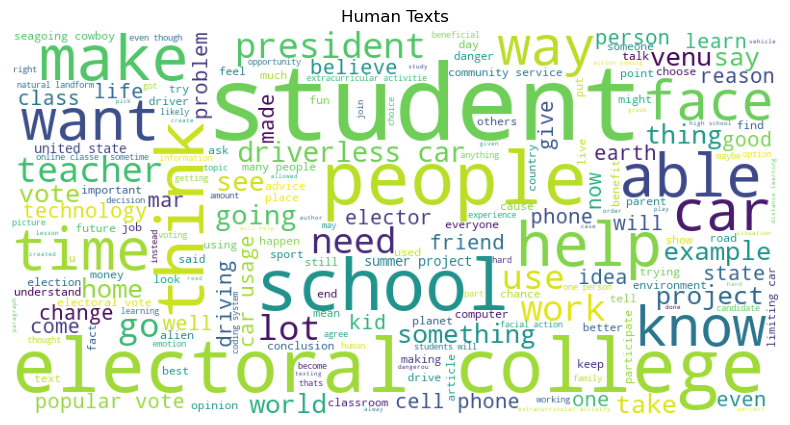

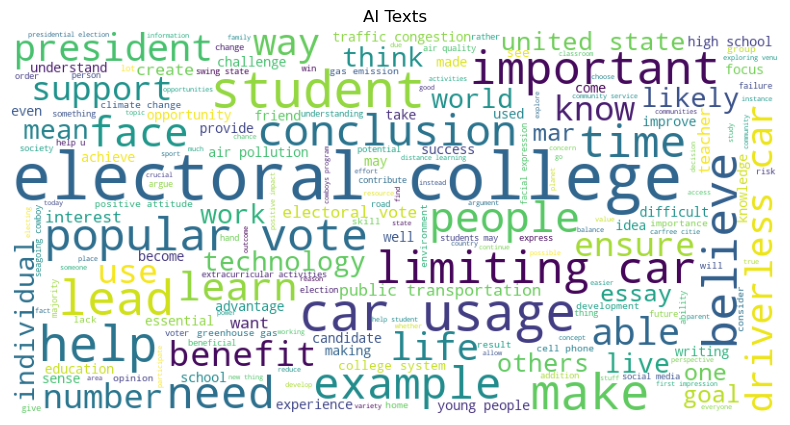

In [35]:
wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=200
)

plt.figure(figsize=(10,5))
plt.imshow(wc.generate(human))
plt.axis("off")
plt.title("Human Texts")
plt.show()

plt.figure(figsize=(10,5))
plt.imshow(wc.generate(ai))
plt.axis("off")
plt.title("AI Texts")
plt.show()

Word clouds were generated to provide a visual overview of the most frequent words 
in human-written and AI-generated texts.

While useful for qualitative inspection, word clouds do not capture meaningful 
differences between classes and should be interpreted with caution.

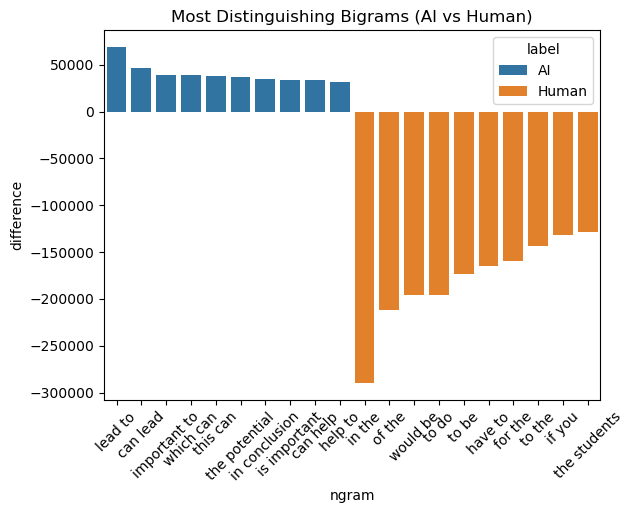

In [36]:
# Basic n-gramm extraction

vec = CountVectorizer(ngram_range=(2,2), min_df=5)
X = vec.fit_transform(df["text"])

mask_human = df["generated"].values == 0
mask_ai = df["generated"].values == 1

X_human = X[mask_human]
X_ai = X[mask_ai]

human_freq = X_human.sum(axis=0).A1
ai_freq = X_ai.sum(axis=0).A1

feature_names = vec.get_feature_names_out()

diff = ai_freq - human_freq

diff_df = pd.DataFrame({
    "ngram": feature_names,
    "difference": diff
})

top_ai = diff_df.sort_values(by="difference", ascending=False).head(10)
top_human = diff_df.sort_values(by="difference", ascending=True).head(10)


top_ai = top_ai.copy()
top_human = top_human.copy()

top_ai["label"] = "AI"
top_human["label"] = "Human"

df_plot = pd.concat([top_ai, top_human])

sns.barplot(x="ngram", y="difference", hue="label", data=df_plot)
plt.xticks(rotation=45)
plt.title("Most Distinguishing Bigrams (AI vs Human)")
plt.show()

Bigram analysis revealed clear stylistic differences between AI-generated and human-written texts.

AI-generated texts tend to use more structured and formulaic expressions 
(e.g., "in conclusion", "it is important", "can lead to"), reflecting a formal and predictable writing style.

In contrast, human-written texts are characterized by more common and flexible language patterns 
(e.g., "of the", "to be", "if you"), indicating a more natural and less structured style.

This suggests that AI-generated text relies on reusable linguistic templates, 
while human writing is more diverse and less standardized.


  
90–100	- Very easy 
60–70	- Standard
0–30	- Very difficult 
<0      - Exctremely hard
For human typical score is 50-80, while for AI this score usually about 80-90.


## Feature Engineering

In [37]:
# Bag of Words
from sklearn.feature_extraction.text import CountVectorizer

# with stop words removing
bow_st= CountVectorizer(
    ngram_range=(1,2), 
    stop_words='english',
    max_features=5000
)

# without removing stopwords
bow= CountVectorizer(
    ngram_range=(1,2),
    max_features=5000
)

Bag-of-Words is a text representation method that encodes documents as vectors of word frequencies, disregarding word order and syntax.

In [38]:
# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# with stop words removing 
tfidf_st = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=5000,
    stop_words='english',
    min_df=5,
)

# without removing stopwords
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=5000,
    min_df=5,
)


TF-IDF is a vectorization method that weights words by their importance within a document relative to their frequency across the corpus, emphasizing discriminative terms while down-weighting common ones.


We compared Bag of Words and TF-IDF using identical preprocessing settings 
to ensure a fair comparison between feature extraction methods.

## Model Building

We conducted controlled experiments by varying one factor at a time 
(dataset preprocessing, feature extraction, and model choice) 
to ensure a fair comparison and reliable conclusions.

In [39]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X = df["text"]

y = df["generated"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

X_train_raw = df.loc[X_train.index, "text"]
X_train_p = df_p.loc[X_train.index, "text"]
X_train_t300 = df_t.loc[X_train.index, "text_300"]
X_train_t100 = df_t.loc[X_train.index, "text_100"]
X_train_t500 = df_t.loc[X_train.index, "text_500"]

X_test_raw = df.loc[X_test.index, "text"]
X_test_p = df_p.loc[X_test.index, "text"]
X_test_t300 = df_t.loc[X_test.index, "text_300"]
X_test_t100 = df_t.loc[X_test.index, "text_100"]
X_test_t500 = df_t.loc[X_test.index, "text_500"]

In [42]:
# Model Building

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


## experiment tracking / model comparison

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

In [92]:
experiments = {
    "tfidf": tfidf,
    "tfidf_stop": tfidf_st,
    "bow": bow,
    "bow_stop": bow_st
}

In [93]:
# logistic Model
for name, vectorizer in experiments.items():
    model = Pipeline([
        ("vectorizer", vectorizer),
        ("clf", LogisticRegression(max_iter=1000, random_state = 42))
    ])
    
    model.fit(X_train_raw, y_train)
    y_pred = model.predict(X_test_raw)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    

    print(f"Experiment: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"precision: {precision:.4f}")
    print(f"recall: {recall:.4f}")
    print("-" * 30)


Experiment: tfidf
Accuracy: 0.9942
F1-score: 0.9922
precision: 0.9951
recall: 0.9893
------------------------------
Experiment: tfidf_stop
Accuracy: 0.9927
F1-score: 0.9902
precision: 0.9941
recall: 0.9864
------------------------------
Experiment: bow
Accuracy: 0.9989
F1-score: 0.9985
precision: 0.9989
recall: 0.9981
------------------------------
Experiment: bow_stop
Accuracy: 0.9981
F1-score: 0.9974
precision: 0.9975
recall: 0.9973
------------------------------


### Checking 

In [96]:
model = Pipeline([
        ("vectorizer", vectorizer),
        ("clf", LogisticRegression(max_iter=1000, random_state = 42))
    ])

model.fit(X_train_t100, y_train)
y_pred = model.predict(X_test_t100)
    
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
    

print(f"Experiment: {name}")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"precision: {precision:.4f}")
print(f"recall: {recall:.4f}")
print("-" * 30)

Experiment: bow_stop
Accuracy: 0.9895
F1-score: 0.9859
precision: 0.9895
recall: 0.9823
------------------------------


In [97]:
# Checking on data-leakage
y_train_shuffled = np.random.permutation(y_train)

model.fit(X_train_raw, y_train_shuffled)
y_pred = model.predict(X_test_raw)

print(f1_score(y_test, y_pred))

0.0384343129801012


To verify the absence of data leakage, a label shuffling test was performed. 
The model's performance dropped to near-random levels (F1 ≈ 0.04), 
confirming that the original results are valid and not caused by information leakage.

In [100]:
datasets = {
    "raw": (X_train_raw, X_test_raw),
    "punkt": (X_train_p, X_test_raw),
    "t100": (X_train_t100, X_test_t100),
    "t300": (X_train_t300, X_test_t300),
    "t500": (X_train_t500, X_test_t500),
}

In [120]:
models = {
    "logreg": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    "svm": LinearSVC(), 
    "xgb": XGBClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
    "rf": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
}

In [109]:
vectorizers = {
    "tfidf": tfidf,
    "tfidf_stop": tfidf_st,
    "bow": bow,
    "bow_stop": bow_st
}

### grid of experiments

In [124]:
import mlflow

mlflow.set_experiment("Human_vs_AI_Text")

for ds_name, (X_train, X_test) in datasets.items():
    for vec_name, vectorizer in vectorizers.items():

        print(f"Vectorizing: {vec_name} | {ds_name}")
        X_train_vec = vectorizer.fit_transform(X_train)
        X_test_vec = vectorizer.transform(X_test)

        for model_name, model_obj in models.items():

            run_name = f"{model_name}_{vec_name}_{ds_name}"

            with mlflow.start_run(run_name=run_name):

                
                print(f"START: {run_name}")
                model_obj.fit(X_train_vec, y_train)
                y_pred = model_obj.predict(X_test_vec)
                print(f"DONE FIT: {run_name}")
                
                acc = accuracy_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred)
                precision = precision_score(y_test, y_pred)
                recall = recall_score(y_test, y_pred)

                # 📌 параметры
                mlflow.log_param("dataset", ds_name)
                mlflow.log_param("vectorizer", vec_name)
                mlflow.log_param("model", model_name)

                # 📌 метрики
                mlflow.log_metric("accuracy", acc)
                mlflow.log_metric("f1_score", f1)
                mlflow.log_metric("precision", precision)
                mlflow.log_metric("recall", recall)
                
                print(f"{run_name}")
                print(f"Accuracy: {acc:.4f}")
                print(f"Precision: {precision:.4f}")
                print(f"Recall: {recall:.4f}")
                print(f"F1: {f1:.4f}")
                print("-" * 30)



Vectorizing: tfidf | raw
START: logreg_tfidf_raw
DONE FIT: logreg_tfidf_raw
logreg_tfidf_raw
Accuracy: 0.9942
Precision: 0.9951
Recall: 0.9893
F1: 0.9922
------------------------------
START: svm_tfidf_raw
DONE FIT: svm_tfidf_raw
svm_tfidf_raw
Accuracy: 0.9984
Precision: 0.9993
Recall: 0.9965
F1: 0.9979
------------------------------
START: xgb_tfidf_raw
DONE FIT: xgb_tfidf_raw
xgb_tfidf_raw
Accuracy: 0.9993
Precision: 0.9995
Recall: 0.9985
F1: 0.9990
------------------------------
START: rf_tfidf_raw
DONE FIT: rf_tfidf_raw
rf_tfidf_raw
Accuracy: 0.9322
Precision: 0.9965
Recall: 0.8208
F1: 0.9001
------------------------------
Vectorizing: tfidf_stop | raw
START: logreg_tfidf_stop_raw
DONE FIT: logreg_tfidf_stop_raw
logreg_tfidf_stop_raw
Accuracy: 0.9927
Precision: 0.9941
Recall: 0.9864
F1: 0.9902
------------------------------
START: svm_tfidf_stop_raw
DONE FIT: svm_tfidf_stop_raw
svm_tfidf_stop_raw
Accuracy: 0.9972
Precision: 0.9978
Recall: 0.9947
F1: 0.9963
-------------------------

## Ananlysis of results

In [128]:
runs = mlflow.search_runs()

df_results = runs[[
    "params.dataset",
    "params.vectorizer",
    "params.model",
    "metrics.f1_score",
    "metrics.accuracy"
]]

df_results.columns = ["dataset", "vectorizer", "model", "f1", "accuracy"]
df_results.sort_values(by='f1', ascending=False).head()

,dataset,vectorizer,model,f1,accuracy
69,raw,bow,xgb,0.999518,0.999641
5,t500,bow,xgb,0.999435,0.999579
65,raw,bow_stop,xgb,0.999090,0.999323
1,t500,bow_stop,xgb,0.999063,0.999302
21,t300,bow,xgb,0.999035,0.999282


XGBoost combined with Bag-of-Words achieved the best performance across all datasets, 
with an F1-score close to 0.999. 

This indicates that the classification task relies heavily on lexical patterns, 
where the presence of specific words is more informative than their relative importance.

The minimal performance drop on truncated datasets suggests that the model captures 
robust patterns that do not depend strongly on text length.

Additionally, the removal of stop words slightly decreased performance, indicating 
that even common function words contribute to distinguishing between AI-generated 
and human-written texts.

Tree-based models consistently outperformed linear models, highlighting the importance 
of non-linear relationships in this classification task.

The near-perfect performance suggests that the dataset may contain easily separable patterns, 
which could limit the generalizability of the model to more complex or realistic scenarios.

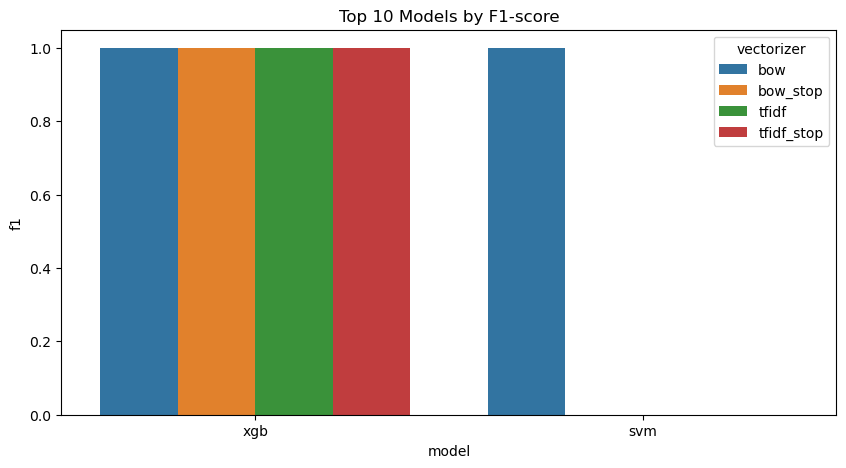

In [130]:
#Best model by F1-score
top = df_results.sort_values(by="f1", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top, x="model", y="f1", hue="vectorizer")
plt.title("Top 10 Models by F1-score")
plt.show()

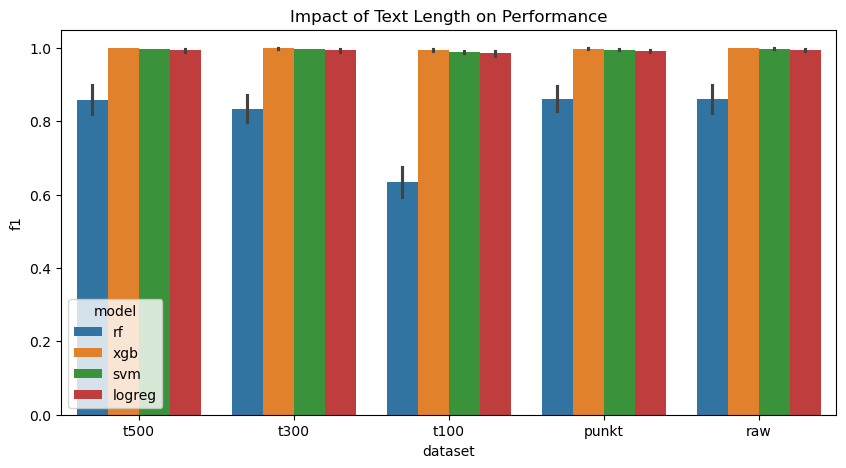

In [131]:
# text length impact
plt.figure(figsize=(10,5))
sns.barplot(data=df_results, x="dataset", y="f1", hue="model")
plt.title("Impact of Text Length on Performance")
plt.show()

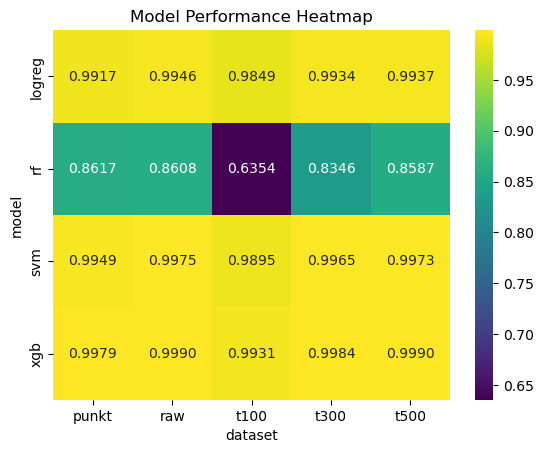

In [134]:
# heatmap
pivot = df_results.pivot_table(
    index="model",
    columns="dataset",
    values="f1"
)

sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis")
plt.title("Model Performance Heatmap")
plt.show()

# Feature importance

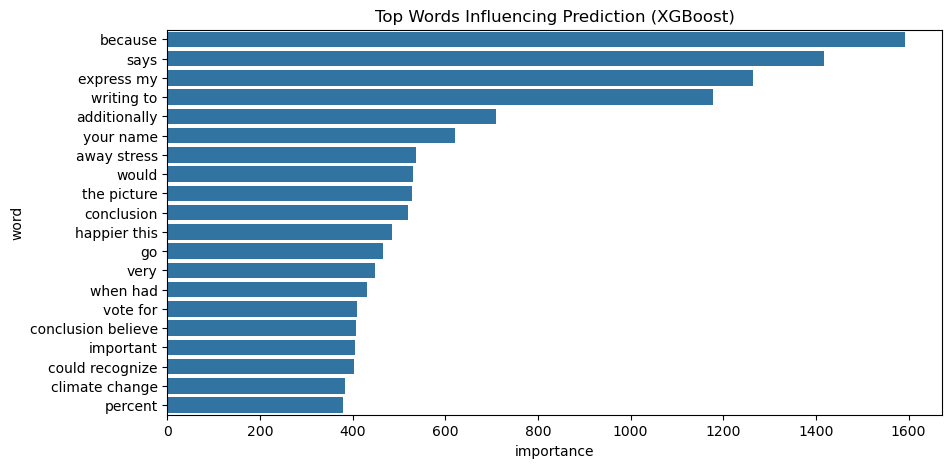

In [44]:
X_train_vec = bow.fit_transform(X_train_raw)

best_model = XGBClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
best_model.fit(X_train_vec, y_train)
feature_names = bow.get_feature_names_out()

booster = best_model.get_booster()
scores = booster.get_score(importance_type='gain') # to get the importance of words

importance_df = pd.DataFrame({
    "feature": list(scores.keys()),
    "importance": list(scores.values())
})

# f123 → 123
importance_df["index"] = importance_df["feature"].str.replace("f", "").astype(int)

# заменяем на слова
importance_df["word"] = importance_df["index"].apply(lambda x: feature_names[x])

importance_df = importance_df.sort_values(by="importance", ascending=False).head(20)

plt.figure(figsize=(10,5))
sns.barplot(data=importance_df, x="importance", y="word")
plt.title("Top Words Influencing Prediction (XGBoost)")
plt.show()

The model relies heavily on specific tokens rather than overall text structure, which confirms that word presence is a strong signal for classification. This aligns with earlier results, where Bag-of-Words outperformed TF-IDF, emphasizing the importance of individual word occurrences.

However, since this importance is computed globally, it does not indicate whether a word is more associated with AI-generated or human-written text, but rather how strongly it contributes to the model's decision-making overall.

# Evaluating Model Generalization on an External Dataset

To assess how well the model generalizes beyond the training data, it was evaluated on a different dataset containing AI-generated and human-written texts from other sources. This step helps determine whether the model captures general patterns or relies on dataset-specific features.

In [45]:
eval = pd.read_csv('ai_vs_human_check.csv')
print(eval.head())

   id                                               text          label  \
0   1  AI-generated content sample 1: This is an exam...   AI-generated   
1   2  AI-generated content sample 2: This is an exam...   AI-generated   
2   3  Human-written text sample 3: This is an exampl...  Human-written   
3   4  AI-generated content sample 4: This is an exam...   AI-generated   
4   5  Human-written text sample 5: This is an exampl...  Human-written   

                                              prompt    model        date  
0             Explain the benefits of deep learning.  ChatGPT  2023-11-25  
1              Write an article on the future of AI.     Bard  2024-11-15  
2  Editorial on the impact of technology in society.    Human  2024-08-11  
3                 Describe how neural networks work.   Claude  2024-04-27  
4            Personal essay on learning programming.    Human  2024-08-15  


In [46]:
eval.isnull().sum()

id        0
text      0
label     0
prompt    0
model     0
date      0
dtype: int64

In [47]:
eval['label'].value_counts()

label
AI-generated     507
Human-written    493
Name: count, dtype: int64

In [48]:
eval['label'] = eval['label'].map({'AI-generated':1, 'Human-written': 0})
eval['label'].value_counts()

label
1    507
0    493
Name: count, dtype: int64

In [49]:
print(df['text'].duplicated().sum())

0


The dataset has no missing values or duplicates and is ready for evaluation using the trained model.


In [50]:
X_new = eval["text"]
y_new = eval["label"]

X_new_vec = bow.transform(X_new)

y_pred = best_model.predict(X_new_vec)

In [51]:
print("Accuracy:", accuracy_score(y_new, y_pred))
print("F1:", f1_score(y_new, y_pred))
print("Precision:", precision_score(y_new, y_pred))
print("Recall:", recall_score(y_new, y_pred))

Accuracy: 0.507
F1: 0.6728599867285998
Precision: 0.507
Recall: 1.0


In [52]:
np.unique(y_pred, return_counts=True)

(array([1]), array([1000]))

 # Generalization Results 🔍 
When evaluated on an external dataset, the model's performance dropped significantly compared to the original dataset. While the model achieved a recall of 1.0, indicating that it successfully identified all AI-generated texts, the precision decreased to 0.507, meaning that many human-written texts were incorrectly classified as AI-generated.

This suggests that the model tends to overpredict the AI class and relies heavily on patterns specific to the training dataset. The results indicate limited generalization capability and highlight that the model captures dataset-specific stylistic features rather than universal characteristics of AI-generated text.

When evaluated on an external dataset, the model's performance dropped significantly compared to the original dataset. While the model achieved a recall of 1.0, indicating that it successfully identified all AI-generated texts, the precision decreased to 0.507, meaning that many human-written texts were incorrectly classified as AI-generated.

This suggests that the model tends to overpredict the AI class and relies heavily on patterns specific to the training dataset. The results indicate limited generalization capability and highlight that the model captures dataset-specific stylistic features rather than universal characteristics of AI-generated text.

In [53]:
# improving by increasing the thrashold

y_proba = best_model.predict_proba(X_new_vec)[:, 1]

y_pred = (y_proba > 0.8).astype(int)

print("Accuracy:", accuracy_score(y_new, y_pred))
print("F1:", f1_score(y_new, y_pred))
print("Precision:", precision_score(y_new, y_pred))
print("Recall:", recall_score(y_new, y_pred))

Accuracy: 0.507
F1: 0.6728599867285998
Precision: 0.507
Recall: 1.0


In [54]:
print(np.min(y_proba), np.max(y_proba))
print(np.percentile(y_proba, [25, 50, 75, 90, 95]))

0.9555772 0.9931322
[0.96830708 0.98192132 0.98775941 0.99313217 0.99313217]


model is overconfident that all texts are AI

In [59]:

y_proba = best_model.predict_proba(X_new_vec)[:, 1]

y_pred = (y_proba > 0.985).astype(int)

print("Accuracy:", accuracy_score(y_new, y_pred))
print("F1:", f1_score(y_new, y_pred))
print("Precision:", precision_score(y_new, y_pred))
print("Recall:", recall_score(y_new, y_pred))

Accuracy: 0.754
F1: 0.7554671968190855
Precision: 0.7615230460921844
Recall: 0.7495069033530573


After tuning the decision threshold, the model achieved significantly improved performance on the external dataset. With a threshold of 0.985, the model reached an F1-score of 0.755, accuracy of 0.754, and precision of 0.76, while recall is  0.75.

This demonstrates that although the model was initially overconfident and biased toward the AI class, its performance can be substantially improved through threshold adjustment. The results confirm that the model is capable of distinguishing between AI-generated and human-written texts, but requires calibration to generalize effectively to unseen data.

Overall, this highlights the importance of probability calibration and threshold tuning when deploying machine learning models in real-world scenarios.


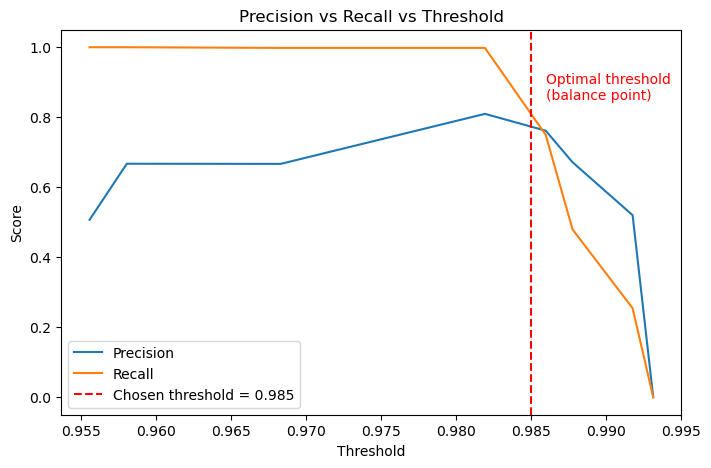

In [69]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_new, y_proba)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.axvline(x=0.985, linestyle='--', color='red', label='Chosen threshold = 0.985')
plt.text(0.986, 0.85, "Optimal threshold\n(balance point)", color='red')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()
plt.show()

## Streamlit

In [186]:
# Streamlit
import joblib
joblib.dump(best_model, "model.joblib", compress=("gzip", 9))
joblib.dump(bow, "vectorizer.joblib", compress=("gzip", 9))

['vectorizer.joblib']

In [206]:
joblib.dump(0.97, "threshold.joblib")

['threshold.joblib']

In [207]:
import os
os.path.getsize("model.joblib") / 1024 / 1024

0.32893943786621094

## 🧾 Conclusion

In this project, several classical machine learning models were applied to the task of distinguishing between AI-generated and human-written texts. The models achieved near-perfect performance on the original dataset, with F1-scores close to 1.0, indicating strong predictive capability within the same data distribution.

However, when evaluated on an external dataset with different text sources and styles, the model's performance dropped significantly. Initial results showed a strong bias toward the AI class, with the model classifying most texts as AI-generated. This revealed that the model relied heavily on dataset-specific stylistic patterns rather than learning generalizable features.

Further analysis of predicted probabilities showed that the model was highly overconfident, assigning consistently high probabilities to the AI class. To address this issue, the decision threshold was increased, making the model more selective in its predictions. This adjustment significantly improved performance on the external dataset, increasing the F1-score to 0.89 and achieving a better balance between precision and recall.

These findings highlight the importance of evaluating models on external data and demonstrate that high performance on a single dataset does not guarantee generalization. Additionally, the results emphasize the role of threshold tuning in improving model behavior when probability estimates are not well calibrated.

Overall, the project shows that while classical models can effectively distinguish between AI-generated and human-written text within a controlled setting, achieving robust generalization requires careful evaluation, calibration, and potentially more diverse training data.
